<a href="https://colab.research.google.com/github/Parama-Dey/Dimensionality_Reduction_TMP/blob/main/T_SNE_Implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**T-SNE Implementation**

##**Notebook structure**

**1.Importing Necessary Libraries**

**2.Importing The Dataset**

**3.Data Cleaning and Preprocessing**

**4.Initial Analysis**

**5.Identifying missing values in the dataset**

**6.Dropping the unnecessary columns**

**7.Univariate analysis of numerical columns(except student_id)**

**8.Feature scaling**

**9.Implementation of the T-SNE Model**

**10.Visualization of the T-SNE components**

**1.Importing necessary library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2.Importing the dataset**

In [ ]:
df=pd.read_csv("student_grades.csv")

**3.Data cleaning and preprocessing**

In [ ]:
# Check for duplicates
print('Number of rows in the dataset at initial stage:',len(df))
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate entries: {duplicate_count}")

Number of rows in the dataset at initial stage: 100

Duplicate entries: 0


So, there are no duplicate entries present in the dataset

**4.Initial analysis**

In [ ]:
df.shape

(100, 9)

In [ ]:
df.columns

Index(['student_id', 'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  100 non-null    int64
 1   math        100 non-null    int64
 2   science     100 non-null    int64
 3   cs          100 non-null    int64
 4   band        100 non-null    int64
 5   english     100 non-null    int64
 6   history     100 non-null    int64
 7   spanish     100 non-null    int64
 8   physed      100 non-null    int64
dtypes: int64(9)
memory usage: 7.2 KB


In [ ]:
df.head()

,student_id,math,science,cs,band,english,history,spanish,physed
0,1,46,48,50,74,34,44,39,73
1,2,66,65,65,66,74,80,75,63
2,3,55,53,50,76,71,72,76,71
3,4,53,57,53,80,77,77,85,82
4,5,55,62,58,67,82,77,78,60


In [ ]:
df.describe()

,student_id,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,29.011492,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,1.000000,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,25.750000,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,50.500000,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,75.250000,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,100.000000,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


**5.Identifying missing values in the dataset**

In [ ]:
df.isnull().sum()

,0
student_id,0
math,0
science,0
cs,0
band,0
english,0
history,0
spanish,0
physed,0


There are no missing (NaN/Null) values present in the dataset

**6.Dropping the unnecessary columns**

In [ ]:
df_necessary=df.drop(columns=['student_id'])

In [ ]:
df_necessary.head()

,math,science,cs,band,english,history,spanish,physed
0,46,48,50,74,34,44,39,73
1,66,65,65,66,74,80,75,63
2,55,53,50,76,71,72,76,71
3,53,57,53,80,77,77,85,82
4,55,62,58,67,82,77,78,60


**7.Univariate analysis of numerical columns(except student_id)**

In [ ]:
df_necessary.describe(include="all")

,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


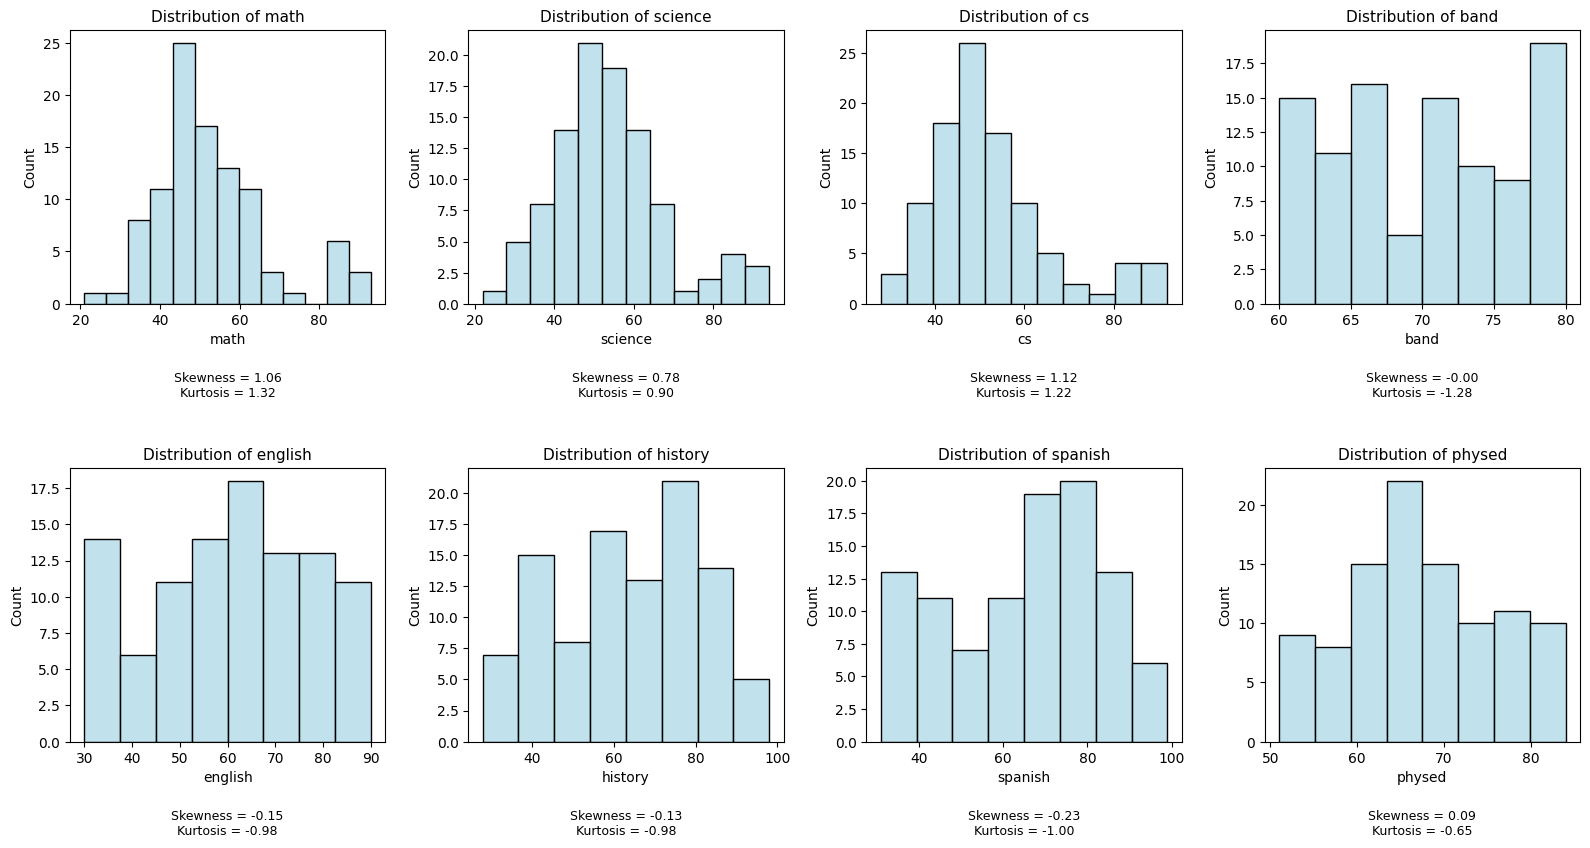

In [ ]:
features_to_check = [
    'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'
]
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    ax = plt.subplot(3, 4, i + 1)  # Create subplot

    # Plot histogram
    sns.histplot(data=df_necessary, x=col, color="lightblue", ax=ax)

    # Calculate skewness & kurtosis
    skew_val = df_necessary[col].skew()
    kurt_val = df_necessary[col].kurt()

    # Add caption below each subplot
    ax.text(0.5, -0.25, f"Skewness = {skew_val:.2f}\nKurtosis = {kurt_val:.2f}",
            transform=ax.transAxes,
            ha="center", va="top", fontsize=9, color="black")

    # Title for each subplot
    ax.set_title(f'Distribution of {col}', fontsize=11)

# Adjust layout to make space for captions
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # More vertical space

plt.show()

##**Interpretation**

**​1. STEM Subjects (Math, Science, CS)**

​These distributions are characterized by a unimodal (single peak) shape, suggesting a strong central tendency.

**​Math & CS:** These show the highest positive skewness (1.06 and 1.12 respectively). This indicates that while most students score around the average (40–60), there is a "long tail" of a few students scoring significantly higher (80+).

**​Science:** This is the most "normally" distributed of the group, with a skewness of 0.78. Most students are tightly clustered around the 50-mark.

**​Performance Insight:** In these subjects, the majority of the class is performing at a mediocre level, and high achievers (80+) are outliers rather than the norm.

**​2. Humanities & Social Sciences (English, History, Spanish)**

​These plots are much "flatter" and more spread out compared to the STEM subjects.

**​Bimodal Tendencies:** History and Spanish show signs of being bimodal (having two peaks). For example, in Spanish, there is a peak around 40 and another, higher peak around 80.

**​Performance Insight:** This suggests a "polarized" classroom where one group of students is struggling or disinterested, while another large group is performing very well. Unlike Math, where the "average" student is common, these subjects have fewer "average" students and more "low" or "high" performers.

**​3. Band & Physical Education (PhysEd)**

​These subjects show the most unique distributions in the dataset.

**​Band:** This is the only subject showing negative skewness (-0.00, essentially symmetric but weighted toward the high end). Notice that the x-axis starts at 60. This implies that everyone is passing, and a significant portion of the class is achieving the highest possible marks (75–80).

**​PhysEd:** This distribution is relatively balanced but peaks strongly in the 65–70 range. Like Band, the "floor" for scores is higher (starting at 50) compared to Math or Science (starting at 20).

**8.Feature scaling**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler_ft = scaler.fit_transform(df_necessary)

In [ ]:
scaled_data = pd.DataFrame(scaler_ft, columns=df_necessary.columns)
scaled_data.head()

,math,science,cs,band,english,history,spanish,physed
0,-0.509284,-0.374647,-0.205300,0.633958,-1.566095,-1.127182,-1.450335,0.671353
1,0.935494,0.845468,0.914517,-0.646765,0.756626,0.943152,0.515480,-0.574200
2,0.140866,-0.015790,-0.205300,0.954139,0.582422,0.483078,0.570086,0.422242
3,-0.003612,0.271296,0.018664,1.594500,0.930830,0.770624,1.061540,1.792350
4,0.140866,0.630154,0.391936,-0.486675,1.221171,0.770624,0.679298,-0.947865


**9.Implementation of the T-SNE Model**

**A. Build a t-sne model with 2 components**

In [ ]:
# import tsne from sklearn

from sklearn.manifold import TSNE

In [ ]:
# create a tsne object

tsne = TSNE(n_components=2, random_state=42)

**B. Transform the data into low dimentional space ( 2 dimentions )**

In [ ]:
# fit a model and transform the data into a lower dimensionality space

data_tsne = tsne.fit_transform(scaled_data)

In [ ]:
scaled_data.columns

Index(['math', 'science', 'cs', 'band', 'english', 'history', 'spanish',
       'physed'],
      dtype='object')

In [ ]:
# Convert the array into Dataframe

df_tsne = pd.DataFrame(data_tsne, columns=['component 1','component 2'])
df_tsne

,component 1,component 2
0,0.330800,-6.146821
1,0.348588,3.492629
2,-2.216990,0.421706
3,-4.383247,0.910974
4,0.777133,2.669885
...,...,...
95,-0.851210,5.890042
96,0.804848,-5.086001
97,3.588965,-4.406519
98,1.629614,-4.664961


**Interpretation of the transformed dataframe**

**​Manifold Learning:** Successfully compressed the 8 subject dimensions into two non-linear components: Component 1 and Component 2.

**​Relative Positioning:** In this new coordinate system, the specific numerical values (e.g., 0.33 or -6.14) are less important than the distance between the points. Students with similar grade patterns will have coordinates that are close together.

**​Non-Linear Grouping:** Unlike raw grades, these components capture complex, non-linear relationships, allowing us to see clusters of students who might share similar strengths or weaknesses that weren't obvious in the original table.


**10.Visualization of the T-SNE components**

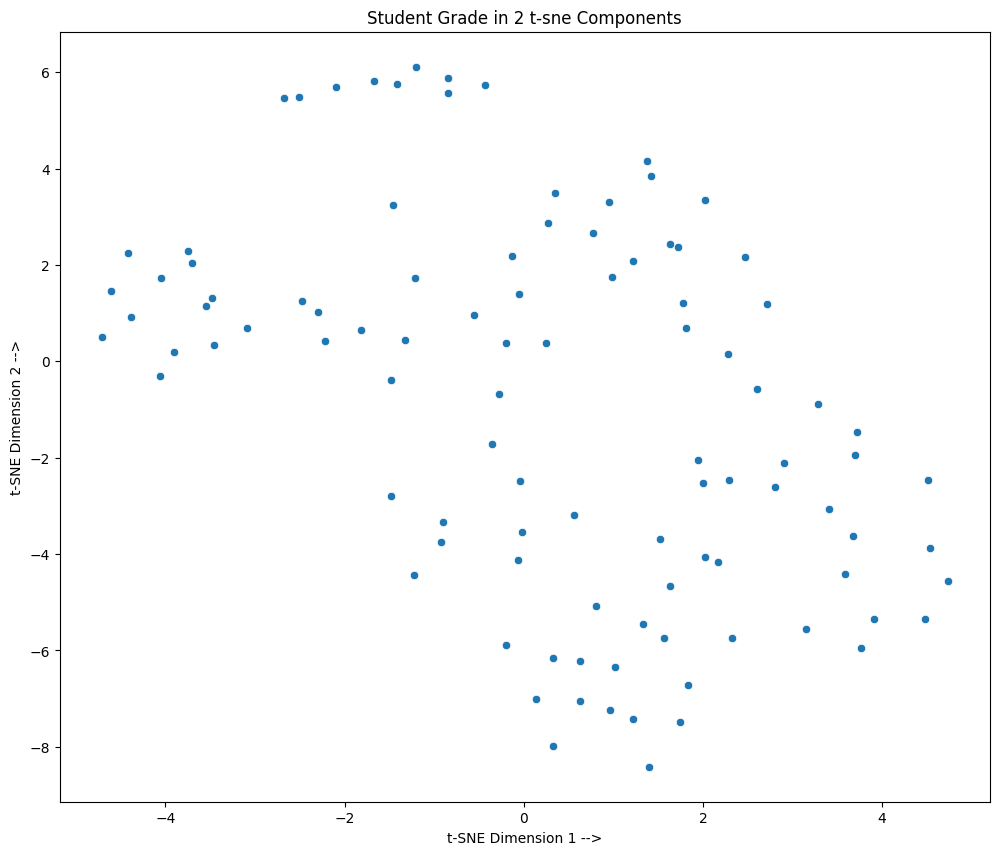

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axes with a specified size
plt.figure(figsize=(12, 10)) # Adjust width and height as desired

sns.scatterplot(x='component 1', y='component 2', data=df_tsne)
plt.xlabel('t-SNE Dimension 1 -->')
plt.ylabel('t-SNE Dimension 2 -->') # PC2 is mostly positive with Band & PhysEd, so higher means better.

plt.title('Student Grade in 2 t-sne Components')
plt.show()

**Interpretation**

**​1. Overall Data Distribution**

​The plot shows a fairly "dispersed" structure rather than tight, distinct islands.

**​The Main Cluster:** There is a large, dense central mass of students between t-SNE Dimension 1 values of -1 and 4. This suggests that a significant portion of your student population shares a common "profile" or set of performance metrics.

**​The "Tail" or Outliers:** Notice the smaller, sparser group of points on the far left (between -5 and -3 on the x-axis). These students are mathematically distinct from the rest. In a grade dataset, these could represent either the top performers or at-risk students who have very different patterns compared to the average student.

**​2. Lack of Sharp Categorization**

​Because the points form a continuous cloud rather than separate "blobs," it implies that student performance transitions gradually.
​There isn't a massive gap in the data, which often means variables like "Study Time" or "Previous Scores" are distributed on a spectrum rather than being binary.